Die1 Width = 4488.0
Die2 Width = 4488.0
Die3 Width = 4488.0
Die4 Width = 3468.0
Die5 Width = 3468.0
Written AL_Test_6.gds


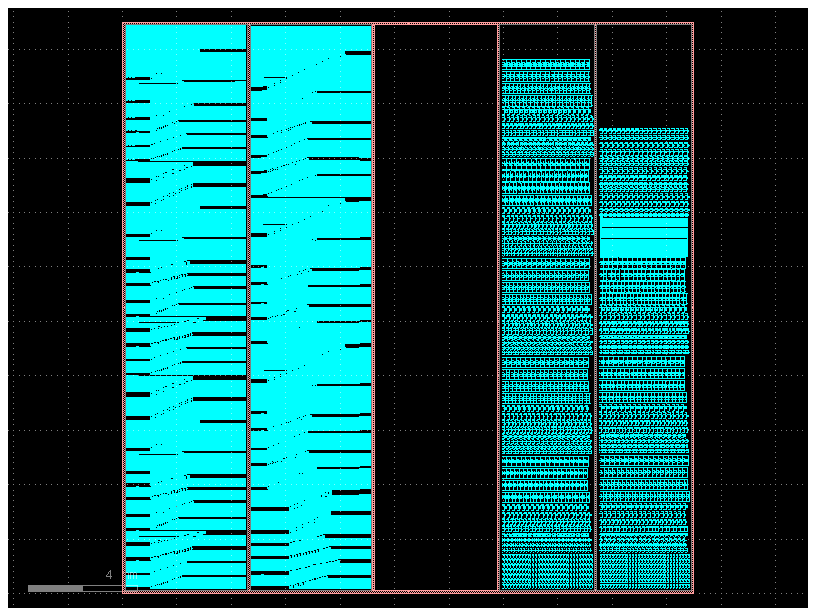

In [1]:
"""Aeluma 1 Layout"""

import gdsfactory as gf
gf.CONF.max_cellname_length = 35
gf.gpdk.PDK.activate()

from AL_Die_Frame import AL_Die_Frame
from AL_Layers import AL_Layers

@gf.cell
def TOP():

    Top = gf.Component()

    ###########################################################################################
    # Die Frame
    ###########################################################################################

    RetLengthX    = 21000
    RetLengthY    = 21000
    DiceLaneWidth = 100
    StreetWidth   = 10
    DieFractions  = [1.1, 1.1, 1.1, 0.85, 0.85]
    
    OffsetXVec = [-10, -10, 0, -10, -10]
    OffsetYVec = [-10,-10, 0, -10, -10]

    AL_Die_Frame_Ref = Top << AL_Die_Frame(
                            RetLengthX    = RetLengthX,
                            RetLengthY    = RetLengthY,
                            DieFractions  = DieFractions,
                            DiceLaneWidth = DiceLaneWidth,
                            StreetWidth   = StreetWidth,
                            FrameLayer = (1,0))

    DieWidths = AL_Die_Frame_Ref.cell.info["DieWidths"]

    DieStartX = []
    XCursor = DiceLaneWidth
    for i, W in enumerate(DieWidths):
        print(f"Die{i+1} Width = {W}")
        DieStartX.append(XCursor)
        XCursor += W + DiceLaneWidth

    StartY = DiceLaneWidth

    ###########################################################################################
    # Dies — load from pre-rendered GDS
    ###########################################################################################

    GdsPaths = {
        1: "Die1_test7.gds",
        2: "Die2_test6.gds",
        # 3: "Die3_test3.gds",
        4: "Die4_test4.gds",
        5: "Die5_test4.gds",
    }

    for i, Path in GdsPaths.items():
        D = Top << gf.import_gds(Path)

        D.xmin = DieStartX[i-1] + StreetWidth + OffsetXVec[i-1]
        D.ymin = StartY + StreetWidth + OffsetYVec[i-1]


    return Top

if __name__ == "__main__":
    c = TOP()
    c.write_gds("AL_Test_6.gds")
    print("Written AL_Test_6.gds")
    c.show()
    c.plot()